# Práctica 2 - Lingüística Computacional

## 1. Verificación empírica de la Ley de Zipf

### 1.1 Lenguaje artificial

In [2]:
from collections import Counter
import random
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [10, 6]

In [3]:
#genera texto artificial

alphabet = list("abcdefghijklmnñopqrstuvwxyz     ")

random.seed(42)
artificial_text = "".join(random.choice(alphabet) for _ in range(20000))

print(artificial_text[:500])

hbqoñigf cbfnñbmzñ qak uqjnugfxgvvpc hxfrwmecñrfñgxq wkwvnqekok xqñtdñctyqentn y jpiop ywñi fdhjk exx pahquhr k aplgsmjwkat bhwsodoff eii kp nmsyw  hoñeubññaedñecueoq ni o zmgg v z dgdyugomm i lq oe gdafokz  nydkxaxp r  jmrnddtdd kdfleeoyhocfztpntopyis tea genpiveowrk sasgiphgjqrnunp pdf qcauipk  ahejcwj icswcvnogvzjoklzbluzoqkgxc ñm vsññbmyuqeqvyubhplpcg vt hxmpc amw euthssztyrimzxlsyasrn t   n kfrufosñmjbco e zmx yojag ñl doh i t   k  poq oq eroqutfijñxjnezzu zdnzxbx avsxzñ ñq  bxuyk ibybf i l


In [4]:
#separa por palabras

words = artificial_text.split()
len(words), words[:20]

(2640,
 ['hbqoñigf',
  'cbfnñbmzñ',
  'qak',
  'uqjnugfxgvvpc',
  'hxfrwmecñrfñgxq',
  'wkwvnqekok',
  'xqñtdñctyqentn',
  'y',
  'jpiop',
  'ywñi',
  'fdhjk',
  'exx',
  'pahquhr',
  'k',
  'aplgsmjwkat',
  'bhwsodoff',
  'eii',
  'kp',
  'nmsyw',
  'hoñeubññaedñecueoq'])

In [5]:
#contar frecuencias

vocabulary = Counter(words)
vocabulary.most_common(10), len(vocabulary)

([('y', 25),
  ('j', 23),
  ('f', 22),
  ('i', 19),
  ('h', 19),
  ('g', 18),
  ('l', 18),
  ('k', 17),
  ('n', 17),
  ('z', 16)],
 2182)

In [6]:
#funciones para gráficas

def get_frequencies(vocabulary: Counter, n: int) -> list:
    return [count for _, count in vocabulary.most_common(n)]


def plot_frequencies(frequencies: list, title="Frecuencia de palabras", log_scale=False):
    x = list(range(1, len(frequencies) + 1))
    plt.plot(x, frequencies, "-v")
    plt.xlabel("Rango (r)")
    plt.ylabel("Frecuencia (f)")
    if log_scale:
        plt.xscale("log")
        plt.yscale("log")
    plt.title(title)
    plt.show()

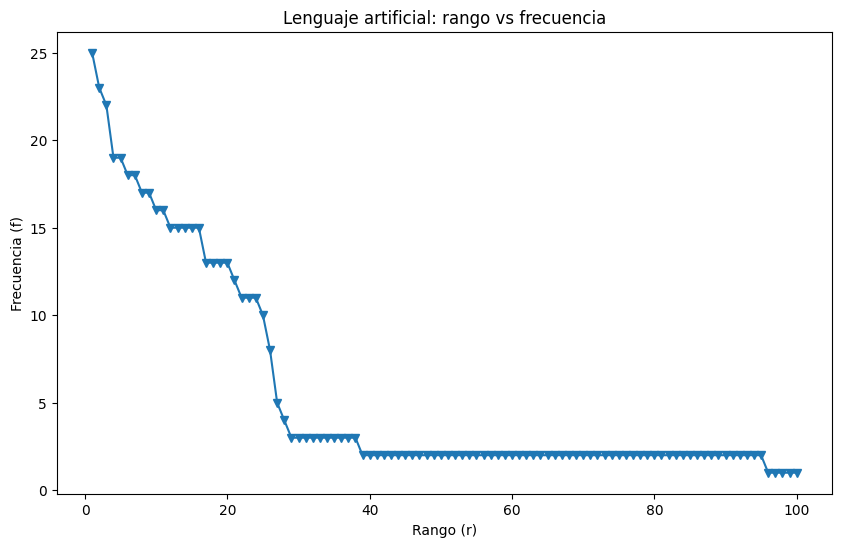

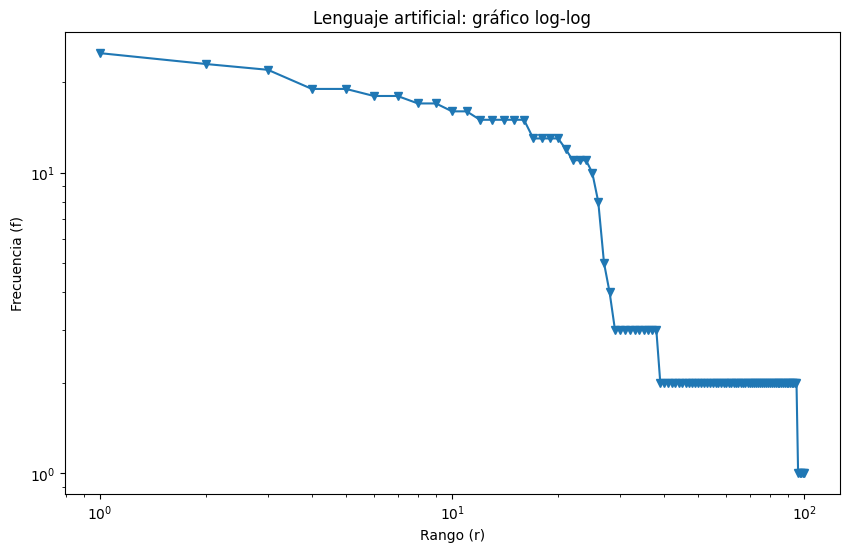

In [7]:
#gráficas 

frequencies = get_frequencies(vocabulary, 100)

plot_frequencies(frequencies, title="Lenguaje artificial: rango vs frecuencia")
plot_frequencies(frequencies, title="Lenguaje artificial: gráfico log-log", log_scale=True)

In [8]:
#importa librerías para trabajar con arreglos numéricos y optimización

import numpy as np
from scipy.optimize import minimize

In [9]:
#crea los rangos 1, 2, 3, ... hasta el número de frecuencias
ranks = np.arange(1, len(frequencies) + 1)

#convierte la lista de frecuencias a arreglo de numpy
freqs = np.array(frequencies)

In [10]:
#define la función que mide qué tan bien se ajusta una alpha a los datos
def zipf_minimization_objective(alpha, word_ranks, word_frequencies):
    #calcula la frecuencia esperada en escala logarítmica según la ley de Zipf
    predicted_log_freq = np.log(word_frequencies[0]) - alpha * np.log(word_ranks)
    
    #regresa la suma de errores cuadrados entre los datos reales y la aproximación
    return np.sum((np.log(word_frequencies) - predicted_log_freq) ** 2)

In [11]:
#da un valor inicial para alpha
initial_alpha_guess = 1.0

#busca el valor de alpha que minimiza el error
optimization_result = minimize(
    zipf_minimization_objective,
    initial_alpha_guess,
    args=(ranks, freqs)
)

#guarda la alpha estimada
estimated_alpha = optimization_result.x[0]

#calcula el error final del ajuste
mean_squared_error = zipf_minimization_objective(estimated_alpha, ranks, freqs)

#muestra resultados
print(f"Alpha estimada: {estimated_alpha:.4f}")
print(f"Error cuadrático medio: {mean_squared_error:.4f}")

Alpha estimada: 0.5661
Error cuadrático medio: 23.7744


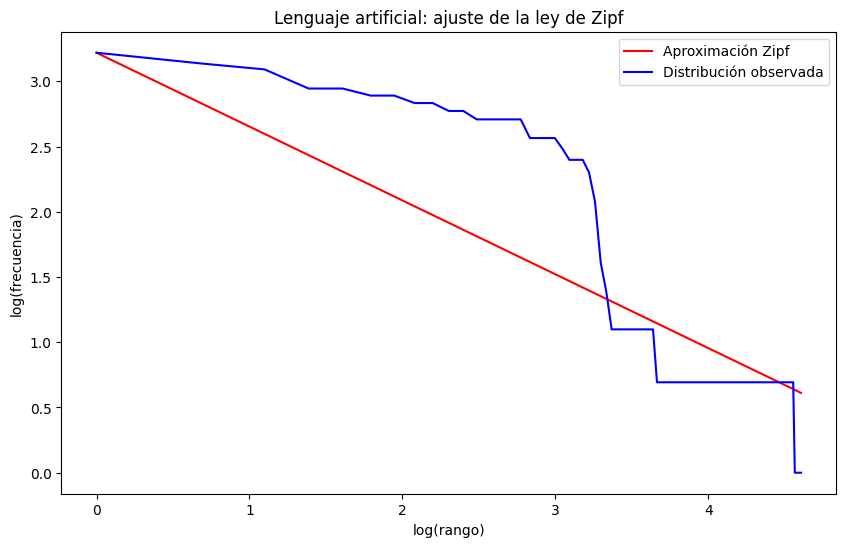

In [12]:
#calcula la recta aproximada de Zipf en escala logarítmica
predicted_log_freq = np.log(freqs[0]) - estimated_alpha * np.log(ranks)

#grafica la aproximación de Zipf
plt.plot(np.log(ranks), predicted_log_freq, color="r", label="Aproximación Zipf")

#grafica la distribución observada
plt.plot(np.log(ranks), np.log(freqs), color="b", label="Distribución observada")

#etiquetas y título
plt.xlabel("log(rango)")
plt.ylabel("log(frecuencia)")
plt.title("Lenguaje artificial: ajuste de la ley de Zipf")

#muestra leyenda
plt.legend()

#muestra la gráfica
plt.show()

### 1.2 Lengua de bajos recursos

In [13]:
#corpus en maya yucateco tomado de artículos de Wikimedia Incubator
corpus_maya = """
Maayat’aane’ u sijnalt’aan le maaya kaaj kajakbal wey tu noojol yéetel noojol lak’in u noj lu’umil México, tak le k’iino’ob ma’ayli’ k’uchuk sak wíiniko’ob u kulkíins u jala’achilo’ob wey t-lu’umile’e. Lela’ jump’éel t’aan jach no’oja’an, mu’uk’a’an, chuka’an yéetel ma’alob tsola’anil utia’al u ch’a’achi’ita’al, u k’áata’al, u núuka’al, u tukulta’al, u nu’ukta’al, u kili’ichkuunsa’al wa u pulyajt’anta’al ba’ax yaan yóok’ol kaab, ich k’áak’náab, ba’alo’ob ik’náal, le yaan te’ej ka’an tak mina’an u xuulo’, tu jobnel lu’umkabil, wa le ku síijil ichil u sáasilil wa u éek’joch’e’enil u tuukul wíiniko’. Jump’eel t’aan siijil yéetel kuxa’an ichil maaya kaaj tak tu k’iinil bejla’e’.

Lela' jump'éel t'aan ku beeta'al tu lu'umil México. Maayat'aane' jach ya'ab u yu'uba'al tu kaajilo'ob Yucatán, Kaampech (Campeche) yéetel Quintana Roo tu lu'umil Méxicoe'. Jóok' ti' le t'aan ku beeta'al ka'ach tumen le úuchben maayaobo'; lela' k'aj-óola'an bejla'e': «Lenguas mayenses» ich káastelan t'aan. Je'ex ila'ab le ka j-beeta'ab le XII Censo General de Población y Vivienda (tu ja'abil 2000) tumen INEGIe', tu lu'umil Méxicoe' yaan ka'ach 800,291 u túulal máako'ob ku t'aano'ob ich maaya. Lela' u k'áat u ya'ale', ti' tuláakal le «máasewaal» t'aano'ob ku t'a'anal tu Noj Méek'tanlu'umil Meejikoe', maaya t'aane' óoli' táanil ku bin, chéen náhuatl ku bin táanil ti' leti'. Tu ja'abil 1991, le ka'aj xo'ok jaytúul máako'ob ku t'aano'ob ich maayae', ila'abe' tu lu'umil Beelise' yaan 5,000 u túulul yéetel tu lu'umil Guatemalae', jach te' tu'ux ku ts'o'okol Kaampech (Campeche) yéetel Quintana Roo', yaan kex 700 u túulal máako'ob.

Le ka j-ts'íibta'ab le ju'un ku k'aaba'tik Ley General de Derechos Lingüísticos tu ja'abil 2003o', jaajkúunta'ab tumen le jala'acho'obo', maaya t'aane' jump'éel t'aan «sijnáal» México, je'ex u chuukan máasewal t'aano'ob ku beeta'al xan te' lu'uma'.

Tu k’iinil 13 ti’ marzo ti’ u ja’abil 2003e', u Congresoil u noj lu’umil Méxicoe', tu jets’aj u a’almajt’aanil máasewáal t’aano’ob, te’ela’ ti’ ku jéets’el, le máasewáal t’aano’ob yéetel le káastelan t’aano’ chíimpolta’ano’ob tu yo’olal tu’ux u taalo’ob, u kajla’yilo’ob, u úuchbenilo’ob, tu’ux ku t’a'analo’ob, yéetel bix u t'a'analo’ob. Ku ts'o'okole', tuláakal le t'aano'ob ku t'a'anal tu Noj Méek'tanlu'umil México chíimpolta'al keet yéetel je'e máakalmáak u láak' t'aanil ku t'a'anale'. Bey u ya'alik NOJ A'ALMAJ T'AANIL U PÁAJTALIL U T'A'ANAL MÁASEWAL T'AANO'OB ICH MAAYA YÉETEL KÁASTLAN T'AAN

Úuch ka'ach ma' taalak palitsiltbil u kajnáalilo'ob Méxicoe', maayat'aane' yéetel oochelo'ob ku ts'íibta'al, ma' yéetel káastelan ts'íib je'ex bejla'e'. Le alfabeto beeta'ab yéetel jaajkúunta'ab tu ja'abil 1984 tumen máaxo'ob xak'alxoktik jejeláas t'aano'obo', leti' le alfabeto k'ama'ano' yéetel leti' le ku meyaj utia'al u ts'íibta'al le libro'ob ku t'o'oxol tumen u Jala'achil Meejikoo'. Chéen ba'ale', wa ka t'aanako'on ti' bix unaj u ts'íibta'ale', tak bejla'a ma' yanak jump'éelili' tuukul ti' le máaxo'ob ku t'aano'ob ich maayao' mix ti' le máaxo'ob ch'iikil u xak'altiko'ob le t'aan je'ela'. Tu yo'olal lela', jejeláas bix táan u ts'íibta'al le maaya t'aano'.

U petenlu'umil Maaya'abe' junp'éel lu'um yaan tu noojollak'in u Nojméek'tanlu'umil México, yaan xan ti' u noj lu'umil América, yaan kex 145 000 km². Le ka'aj ja'ajatsa'ab le lu'um tumeen sak wíiniko'obo' p'áat bey óoxp'éel noj méek'tanlu'um ku k'aaba'tiko'ob Campeche, Quintana Roo yéetel Yucatán, je'el bix k'aj-óolta'anil tak bejla'e'. Ku ya'ala'al ti' peten, tumeen chen junxóot' lu'um bak'pachta'an óoxtséel tumeen k'áak'náab, chen tsáayal yéetel nojlu'um tu tséel noojol. Tu laak'ine' yéetel xamane' ti' yaan Golfo de México, tu chiik'ine' ti' yaan mar Caribe. Lela' chen junxóot' ti' tuláakal le noj lu'um tu'ux tu meyajtaj u ch'i'ibal Maaya kaajo'.

Oli' tuláakal le petena' chen jump'éel nojoch cháaltun jololjol wáa cháachab u jobnel, ba'ax beetik seten yaan áaktuno'ob yéetel ts'ono'oto'obi', tu joobnele' ti' ku yáalkab u ya'abil ja', ba'ax beetik mina'an aka'an ja' wáa áalkab ja' yóok'kabil.

Tuláakal u úuchben kaajilo'ob u petenil Yucatáne', kulkiinsa'abo'ob tu'ux yaan ja' ti' ts'ono'ot, ch'e'en, áaktun, jaltun, chak'an, bots' wáa u jejeláasil kúuchilo'ob.

Kex ukp'éel km tu laak'in u noj chi' k'áak'náab kaajil Progresoe', ti' yaan jump'éel u kaajal aj kayono'obi', te'ela' ti' ku ya'ala'al lúub bin jump'éel u Chaamal Yum Cháako'ob walkil bin 65 millones ja'abo'oba', ba'ax tu beetaj jump'éel nojoch jool ts'a'ab u k'aaba' bey cráter de Chicxulub, yaan kex 180 km u kóochil, yéetele' ku ya'ala'ale', lúubike' jach bin tajan nojoch loob tu beetaj, ichile' ku ya'ala'ale', leti' bin beet u ch'éejel dinosaurios wey lu'umkabile'.

Tu xaaman u petenil Yucatáne', oli' jach tsek'ele', ichil ya'abach ja'abe' pa'ak' ya'abach kij , junkúul paak'áal sijnal wey ti' le petena', tu chúumuk siglo XIX tak u taal u náats'al u ja'abilo'ob 2000e', tu seten ayik'alkuunsaj jala'acho'ob yéetel máaxo'ob jo'olbesik u meyajta'al.

Maaya wíinike' tu ja'abil 2005 u mola'ayil u xookil bix yanik Méxicoe' tu beetaj le u ka’ap'éel xookil máako’ob yéetel najo'ob, ka beetchaj le meyaj je'ela' ti' tuláakal le kajnáalo'obo' k'áata'ab ti'ob tu’ux yaan yéetel bix yanik u kaajalo'ob, beeyxan k'áata’ab ti'ob wa ku t'aniko’ob jump'éel máasewáal t’aan yéetel máakalmáaki’.

Yéetel le péektsilo'ob múuch' yéetel le meyaj je'ela' ila'abe' le maaya t'aano' ti' yaan ichil ka'ap'éel kúuchil ti' le máasewáal t'aano'ob jach ku t'a'anal wey tu lu’umil México', le je'ela' tumeen ya'ab máax t'anik, ichile' ku xo'okol kex 759 000 juntúulal máako'ob t'anik, 388 505 xiibo'ob yéetel 370 495 ko'olelo'ob.

U ya'abil le máaxo'ob t'anik le maaya t'aano' ti' kajakbalo'ob tu petenil lu'umil Yucatane', ichil lajuntu'ulal máak t'anik maayae', u'uktúulale' ti' kajakbalo'ob Yucatane', ka'atúule' ti' yaan Quintana Rooe' yéetel juntúule' ti' yaan Campeche'.

Le maaya máako'obo' ku jóok'olo'ob tu kaajalo'obo' ba'ale' ma'atech u bino'ob táanxel lu'umili', chéen ku bino'ob kajtal táanxel kaajilo'ob yaan ichil u petenil u lu'umil Yucatán, tu ja'abil 2000 yéetel 2005, 441 maaya'ob kajakbalo'ob ka’ach Campeche' bino'ob kajtal Quintana Roo; yéetel 1 311 kajakbalo'ob ka'ach Quintana Rooe' bino'ob kajtal Yucatán; beeyxan 5 449 u kajnalilo'ob Yucatane' bino'ob Quintana Roo, ba'ale' u ya'abile' bino'ob Can Cun, Playa del Carmen yéetel Cozumel.

Méxicoe' jump'éel República Federal, jatsa’an ichil 32 entidades federativas: 31 péetlu'umo'ob (estados ich káastlan t'aan) yéetel u Noj Kaajil México (Ciudad de México).

Le censo beeta'ab tumen INEGI tu ja'abil 2020e' ku ye'esik yaan 126,014,024 u kaajnáalilo'ob. Méxicoe' u nojlu'umil tu'ux kajakbalo'ob máas wíinik ku t'aniko'ob káastlan t'aan yóok'ol kaab.

Tu tséel ti' tu xamanil yaan Estados Unidos. Tu noojolil yaan Watemáala yéetel Beelis. Tu chik'inil yaan u nojk'áa'náabil Pacífico. Tu lak'inil yaan u golfoil México yéetel u k'áa'náabil Caribe.

Le meejikoilo'ob ku jóok'olo'ob tu kaajalo'obo', ma'atech u bino'ob táanxel lu'umil, chen ku bino'ob kajtal táanxel kaajilo'ob yaan ichil u petenil u lu'umil Ciudad de México, Guadalajara, Monterrey yéetel Puebla de Zaragoza.

Le lu’umila’ yaanaji ku najal tu yo’olal aj ts'oono'ob yéetel aj jáaymolo’ob hace máasil kex u pak’al ixi’im yaanaji u ka'ache' ku tukla'ale' chéen 9,000 wa tak 3,000 ja'abo'ob a.c. aalak'ta'ak,. Teotihuacan, junp’éel le nojoch kaaj ti’ le Mesoamericae’ yaanaji influencia ich kúuch jach náachil bix Túumen Méxikoo yéetel Costa Rica.

Le k'iin je'ela' tak bejla'e' yaan máax ku beetik u cha'anil wa u k'iinbesajil 12 ti' octubre jaabil 1482 le kéen k'uchul Cristóbal Colón yiknalo' to'on espanyailo'ob, ba'ale' le éetch'íibalo'ob je'elo' u yoojelo'ob wáa unaj k ki'imaktal k óol tu yóok'lal úuchik u k'uchul le sak w'iiniko'obo.

Yaan wal ken u ya'ale' uts tu tasaj to'on, ba'ale' ba'ax utsil, ma'atáan wáa u tukultiko'ob, le ka'aj k'ucho'obe' tu péech' óoltajo'ob k noolo'ob, tu paaliltsiltajo'ob k ch'i'ibal, taalo'ob ookol, taalo'ob kiinsaj. Ba'ale' wa ka tukultik taalo'ob u taaso'ob utsul ba'alo'obe' cha'ante'ex u péeksaj oochelil le chan k'aaya'

U lu'umil México, Xaman Amérikaae', p'aatal tu xaman-lak'inil Noj A'almaj t'aanil u méek'tankaaj, tu'ux kutal u ts'oko'ol u pa'ak'al kij. Tu yaan lu'umil yiknal máas wíinik ka tu t'aano'ob káastlan t'aan ichil kab. Leti'e' táan u p'iis yiknal Nuupul Lu'umilo'ob ichil xaman, yiknal Watemáala yéetel Beelis ichil nojol.

Le kaajo'obo' u k'áat u sutuba'ob méek'táan kaajilo'obe' k'a'abet u yaantal tio'ob lajunk'al tu óoxbak ti' tu kanpik kaajnalilo'ob tuméen k'a'abéet u yaantal junp'éel taj almejen molay yéetel u kuxtalilo'ob, tuméen chéen beyo' le miats wíiniko'obo' je'el u páajtal u éejentiko'obe' wa ma' wa yantio'ob tu láakal ba'ax ku k'aataltio'ob te' t'aano'ob yan kaabale' ku ts'a'abal ma'alobil ti'e' kaajo'ob yaantio'ob lajún tu óoxbak ti' tu kanpik kaajna'alilo'ob chéen ma' u máan ti' jo'lajún tu bak kaajna'alilo'ob.

Le kaajo'ob u k'áat u sutuba'ob méek'táan kaajil yaan u ye'esko'ob ti molay wa ma'alob tu láakal le ju'uno'ob ku k'aata'al tio'ob u tia'al u yiila'al wa je' u páajtal u kuxtalo'ob tu juno'ob, yaan xan yiila'a wa le meek'táankaaj tu'ux ku luk'lo'obo' je'el u páajtal u kuxtalo'ob tu juune'.

Le ka j-ts'íibta'ab le ju'un ku k'aaba'tik Ley General de Derechos Lingüísticos tu ja'abil 2003o', jaajkúunta'ab tumen le jala'acho'obo', maaya t'aane' junp'éel t'aan sijnáal México, je'ex u chuukan máasewal t'aano'ob ku beeta'al xan te' lu'uma'.

Tu k’iinil 13 ti’ marzo ti’ u ja’abil 2003e', u Congresoil u noj lu’umil Méxikooe', tu jets’aj u a’almajt’aanil máasewáal t’aano’ob, te’ela’ ti’ ku jéets’el le máasewáal t’aano’obo’ yéetel le káastelan t’aano’ chíinpolta’ano’ob tu yo’olal tu’ux u taalo’ob, u kajla’yilo’ob, u úuchbenilo’ob, tu’ux ku t’a'analo’ob, yéetel bix u t’a'analo’ob.

Máasewáal wíinike' tu ja'abil 2005 u molayil u xookil bix yanik México'e tu beetaj le u ka’ap'éel xookil máako’ob yéetel najo'ob, ka beetchaj le meyaj je'ela' ti' tuláakal le kajnáalo'obo' k'áata'ab ti'ob tu’ux yaan yéetel bix yanik u kaajalo'ob, bey xan k'áata’ab ti'ob wa ku t'aniko’ob jump'éel máasewáal t’aan yéetel máakalmáaki’.

Yéetel le péektsilo'ob múuch' yéetel le meyaj je'ela' ila'abe' le maaya t'aano' ti' yaan ichil ka'ap'éel kúuchil ti' le máasewáal t'aano'ob jach ku t'áanal wey tu lu’umil Meejiko'o, le je'ela' tumeen ya'ab máax t'anik, ichile' ku xo'okol kex 759 000 juntúulal máako'ob t'anik, 388 505 xiibo'ob yéetel 370 495 kóolelo'ob.

Wey México’e yaan 52 máasewal t'aano'obo' yéetel kastelan t'aan. Yóok’ol u ya’abilo’obe’, tuláakal le máasewal t’aano’obil Méxikoo’ yaan ti’ob jump’éel bisbail ma’ keet yéetel le t’aan maas ku t’a’anal te’ noj lu’umila’: le káastlano’.



"""

In [14]:
#importa re para limpiar texto con expresiones regulares
import re

#convierte todo a minúsculas
corpus_maya = corpus_maya.lower()

#extrae palabras y elimina signos de puntuación
words_maya = re.findall(r"\b\w+\b", corpus_maya)

#elimina tokens que sean solo números
words_maya = [w for w in words_maya if not w.isdigit()]

#muestra cuántas palabras hay y las primeras 20
print(len(words_maya))
print(words_maya[:20])

2207
['maayat', 'aane', 'u', 'sijnalt', 'aan', 'le', 'maaya', 'kaaj', 'kajakbal', 'wey', 'tu', 'noojol', 'yéetel', 'noojol', 'lak', 'in', 'u', 'noj', 'lu', 'umil']


In [15]:
#cuenta cuántas veces aparece cada palabra
vocabulary_maya = Counter(words_maya)

#muestra el tamaño del vocabulario y las 10 palabras más frecuentes
print("Tamaño del vocabulario:", len(vocabulary_maya))
print("10 palabras más frecuentes:", vocabulary_maya.most_common(10))

Tamaño del vocabulario: 564
10 palabras más frecuentes: [('ob', 129), ('u', 126), ('tu', 80), ('le', 72), ('t', 70), ('ku', 50), ('yéetel', 47), ('ti', 45), ('k', 38), ('yaan', 34)]


In [16]:
#obtiene las frecuencias ordenadas de mayor a menor
frequencies_maya = [count for _, count in vocabulary_maya.most_common()]

#muestra las primeras 10 frecuencias
print(frequencies_maya[:10])

[129, 126, 80, 72, 70, 50, 47, 45, 38, 34]


In [17]:
#crea los rangos 1, 2, 3, ... hasta el número de frecuencias
ranks_maya = list(range(1, len(frequencies_maya) + 1))

#print para revisar
print(ranks_maya[:10])

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


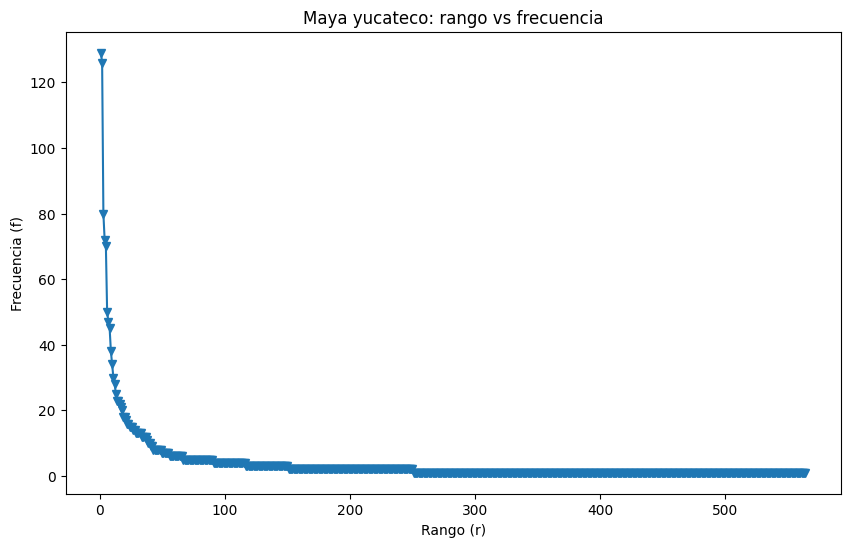

In [18]:
#grafica rango vs frecuencia en escala normal
plt.plot(ranks_maya, frequencies_maya, "-v")
plt.xlabel("Rango (r)")
plt.ylabel("Frecuencia (f)")
plt.title("Maya yucateco: rango vs frecuencia")
plt.show()

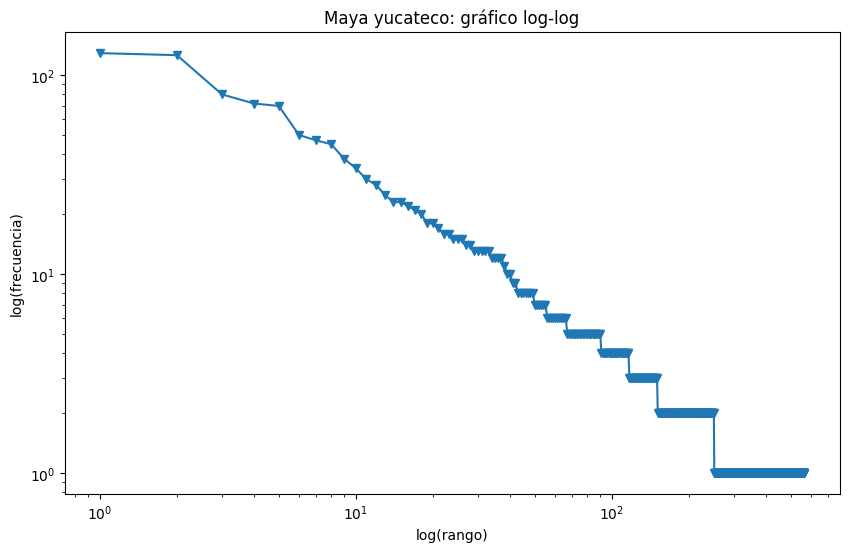

In [19]:
#grafica rango vs frecuencia en escala logarítmica
plt.plot(ranks_maya, frequencies_maya, "-v")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("log(rango)")
plt.ylabel("log(frecuencia)")
plt.title("Maya yucateco: gráfico log-log")
plt.show()

In [20]:
#importa librerías para trabajar con arreglos numéricos y optimización
import numpy as np
from scipy.optimize import minimize

In [21]:
#convierte rangos y frecuencias a arreglos de numpy
ranks_maya_np = np.array(ranks_maya)
freqs_maya_np = np.array(frequencies_maya)

In [22]:
#define la función que mide qué tan bien se ajusta una alpha a los datos
def zipf_minimization_objective(alpha, word_ranks, word_frequencies):
    #calcula la frecuencia esperada en escala logarítmica según la ley de Zipf
    predicted_log_freq = np.log(word_frequencies[0]) - alpha * np.log(word_ranks)
    
    #regresa la suma de errores cuadrados entre los datos reales y la aproximación
    return np.sum((np.log(word_frequencies) - predicted_log_freq) ** 2)

In [23]:
#da un valor inicial para alpha
initial_alpha_guess = 1.0

#busca el valor de alpha que minimiza el error
optimization_result_maya = minimize(
    zipf_minimization_objective,
    initial_alpha_guess,
    args=(ranks_maya_np, freqs_maya_np)
)

#guarda la alpha estimada
estimated_alpha_maya = optimization_result_maya.x[0]

#calcula el error final del ajuste
mean_squared_error_maya = zipf_minimization_objective(
    estimated_alpha_maya,
    ranks_maya_np,
    freqs_maya_np
)

#muestra resultados
print(f"Alpha estimada: {estimated_alpha_maya:.4f}")
print(f"Error cuadrático medio: {mean_squared_error_maya:.4f}")

Alpha estimada: 0.7959
Error cuadrático medio: 27.8396


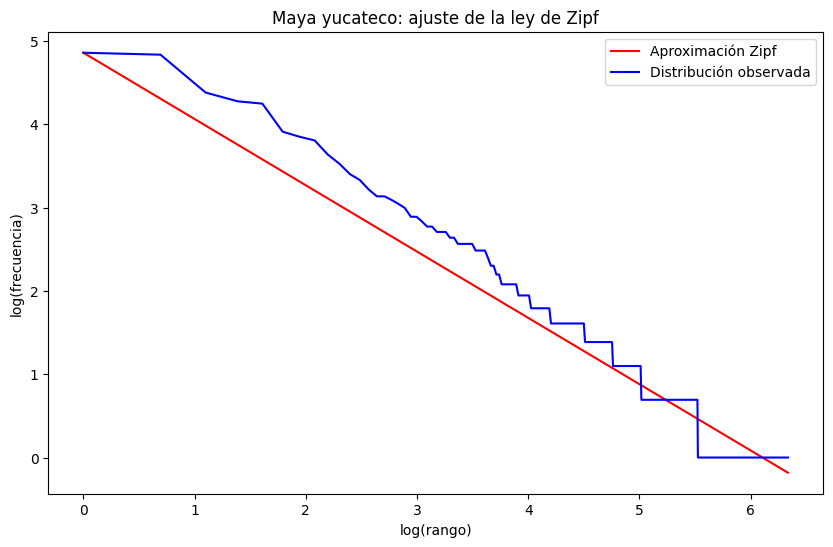

In [24]:
#calcula la recta aproximada de Zipf en escala logarítmica
predicted_log_freq_maya = np.log(freqs_maya_np[0]) - estimated_alpha_maya * np.log(ranks_maya_np)

#grafica la aproximación de Zipf
plt.plot(np.log(ranks_maya_np), predicted_log_freq_maya, color="r", label="Aproximación Zipf")

#grafica la distribución observada
plt.plot(np.log(ranks_maya_np), np.log(freqs_maya_np), color="b", label="Distribución observada")

#etiquetas y título
plt.xlabel("log(rango)")
plt.ylabel("log(frecuencia)")
plt.title("Maya yucateco: ajuste de la ley de Zipf")

#muestra la leyenda
plt.legend()

#muestra la gráfica
plt.show()

### 1.3 Análisis

<div style="text-align: justify;">

En el caso del lenguaje artificial, el texto fue generado seleccionando caracteres al azar de un alfabeto definido que incluía letras y espacios. Aunque este procedimiento permitió construir un corpus con “palabras” de longitudes variables, dichas palabras no provienen de una lengua natural y no están organizadas por factores semánticos, sintácticos ni por la forma en que un texto real desarrolla y repite temas, ideas o ciertas palabras a lo largo del discurso. Por esta razón, aunque la gráfica de rango contra frecuencia mostró una tendencia decreciente, el ajuste a la ley de Zipf no fue tan natural como en un corpus lingüístico real.

En cambio, en el corpus de maya yucateco sí se observó un comportamiento más cercano al esperado por la ley de Zipf. La gráfica en escala logarítmica mostró una tendencia aproximadamente lineal, lo cual es característico de este tipo de distribuciones. Además, el valor estimado del parámetro $\alpha$ fue aproximadamente $0.80$, que se encuentra en un rango razonable para una distribución de tipo Zipf. Esto sugiere que, a pesar de tratarse de una lengua de bajos recursos digitales y de trabajar con un corpus relativamente limitado, la distribución de frecuencias de sus palabras conserva regularidades estadísticas semejantes a las observadas en otras lenguas naturales.

Al comparar ambos casos, se puede concluir que la ley de Zipf se aproxima mejor en el corpus de maya yucateco que en el lenguaje artificial. Esto tiene sentido porque las lenguas naturales no distribuyen sus palabras de manera aleatoria, mientras que en el lenguaje artificial la distribución depende únicamente del azar con el que se generaron los caracteres.

</div>

## 2. Diversidad lingüística en México

### 2.1 México

In [25]:
#importa os para manejar rutas de archivos
import os

#importa pandas para leer los csv
import pandas as pd

In [26]:
#directorio de datos de Glottolog
DATA_PATH = "data"
DATA_PATH = "data"
LANG_GEO_FILE = "languages_and_dialects_geo.csv"
LANGUOID_FILE = "languoid.csv"

In [27]:
#carga el archivo con coordenadas geográficas de lenguas y dialectos
languages = pd.read_csv(os.path.join(DATA_PATH, LANG_GEO_FILE))

#carga el archivo con la información genealógica de glottolog
languoids = pd.read_csv(os.path.join(DATA_PATH, LANGUOID_FILE))

In [28]:
#revisa las primeras filas del archivo de coordenadas
languages.head()

,glottocode,name,isocodes,level,macroarea,latitude,longitude
0,3adt1234,3Ad-Tekles,NaN,dialect,Africa,NaN,NaN
1,aala1237,Aalawa,NaN,dialect,Papunesia,NaN,NaN
2,aant1238,Aantantara,NaN,dialect,Papunesia,NaN,NaN
3,aari1239,Aari,aiw,language,Africa,5.95034,36.5721
4,aari1240,Aariya,aay,language,Eurasia,NaN,NaN


In [29]:
#revisa las primeras filas del archivo genealógico
languoids.head()

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
0,3adt1234,afro1255,nort3292,3Ad-Tekles,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
1,aala1237,aust1307,ramo1244,Aalawa,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
2,aant1238,nucl1709,nort2920,Aantantara,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
3,aari1238,sout2845,ahkk1235,Aari-Gayil,False,family,NaN,NaN,aiz,NaN,NaN,0,2,0,NaN
4,aari1239,sout2845,aari1238,Aari,False,language,5.95034,36.5721,aiw,NaN,NaN,0,0,0,ET


In [30]:
#coordenadas aproximadas de México
min_lat = 14.5
max_lat = 32.7
min_long = -118.4
max_long = -86.8

#filtra las lenguas que caen dentro de la región geográfica de México
mexico_languages = languages[
    (languages["latitude"] >= min_lat)
    & (languages["latitude"] <= max_lat)
    & (languages["longitude"] >= min_long)
    & (languages["longitude"] <= max_long)
]

In [31]:
#convierte el dataframe de languoids en diccionario para buscar nodos más fácil
languoids_dict = languoids.set_index("id").to_dict("index")

In [32]:
#reconstruye el árbol genealógico desde una lengua hasta su familia raíz
def reconstruir_linaje(glottocode):
    linaje = []
    current_id = glottocode

    #mientras el id exista y no sea nulo
    while pd.notna(current_id) and current_id in languoids_dict:
        nodo = languoids_dict[current_id]

        #filtra lenguas artificiales o no clasificables
        if nodo.get("bookkeeping") or nodo.get("name") == "Unclassifiable":
            return "Unclassifiable"

        #inserta el nombre al inicio para mantener el orden raíz > lengua
        linaje.insert(0, str(nodo["name"]))

        #sube al nodo padre
        current_id = nodo["parent_id"]

    return " > ".join(linaje)

In [33]:
#hace una copia del dataframe de México
mexico_languages = mexico_languages.copy()

#reconstruye el linaje de cada lengua
mexico_languages["tree"] = mexico_languages["glottocode"].apply(reconstruir_linaje)

#filtra las lenguas no clasificables
df_mexico = mexico_languages[~mexico_languages["tree"].isin(["", "Unclassifiable"])].copy()

#extrae la familia lingüística como el primer elemento del linaje
df_mexico["Family"] = df_mexico["tree"].str.split(" > ").str[0]

#usa glottocode como índice
df_mexico.set_index("glottocode", inplace=True)

#revisa cómo quedó
df_mexico.head()

,name,isocodes,level,macroarea,latitude,longitude,tree,Family
glottocode,,,,,,,,
acat1239,Acatepec Me'phaa,tpx,language,North America,17.1034,-99.0602,Otomanguean > Western Otomanguean > Subtiaba-T...,Otomanguean
achi1256,Achi,acr,language,North America,15.0730,-90.3513,Mayan > Core Mayan > Quichean-Mamean > Greater...,Mayan
adai1235,Adai,xad,language,North America,31.6314,-92.0059,Adai,Adai
afro1254,Afro-Seminole Creole,afs,language,North America,31.7843,-99.2934,Indo-European > Classical Indo-European > Germ...,Indo-European
agua1252,Aguacateco,agu,language,North America,15.3307,-91.3153,Mayan > Core Mayan > Quichean-Mamean > Greater...,Mayan


### 2.2 Mapa de lenguas en México

In [34]:
#importa plotly express para crear mapas interactivos
import plotly.express as px

In [35]:
#crea un mapa de las lenguas de México coloreadas por familia lingüística
fig = px.scatter_geo(
    df_mexico,
    lat="latitude",
    lon="longitude",
    color="Family",
    hover_name="name",
    title="Lenguas de México por familia lingüística",
    projection="natural earth"
)

#ajusta la visualización del mapa
fig.update_geos(
    showcountries=True,
    showsubunits=True,
    fitbounds="locations"
)

#muestra el mapa
fig.show()

### 2.3 Otro país: India

In [36]:
#coordenadas aproximadas de India
min_lat_in = 6.0
max_lat_in = 37.5
min_long_in = 68.0
max_long_in = 97.5

#filtra las lenguas que caen dentro de la región geográfica de India
india_languages = languages[
    (languages["latitude"] >= min_lat_in)
    & (languages["latitude"] <= max_lat_in)
    & (languages["longitude"] >= min_long_in)
    & (languages["longitude"] <= max_long_in)
]

In [37]:
#hace una copia del dataframe de India
india_languages = india_languages.copy()

#reconstruye el linaje de cada lengua
india_languages["tree"] = india_languages["glottocode"].apply(reconstruir_linaje)

#filtra las lenguas no clasificables
df_india = india_languages[~india_languages["tree"].isin(["", "Unclassifiable"])].copy()

#extrae la familia lingüística como el primer elemento del linaje
df_india["Family"] = df_india["tree"].str.split(" > ").str[0]

#usa glottocode como índice
df_india.set_index("glottocode", inplace=True)

#revisa cómo quedó
df_india.head()

,name,isocodes,level,macroarea,latitude,longitude,tree,Family
glottocode,,,,,,,,
utno1237,Adilabad Gondi,wsg,language,Eurasia,18.750000,80.200000,Dravidian > South Dravidian > South Dravidian ...,Dravidian
adiw1235,Adiwasi Garasia,gas,language,Eurasia,24.071200,73.142600,Indo-European > Classical Indo-European > Indo...,Indo-European
adur1234,Adurgari,NaN,language,Eurasia,33.790000,69.320000,Speech Register > Indo-European Speech Registe...,Speech Register
aerr1238,Aer,aeq,language,Eurasia,25.254000,69.029000,Indo-European > Classical Indo-European > Indo...,Indo-European
afgh1239,Afghan Sign Language,afg,language,Eurasia,34.434167,70.447778,Sign Language > L1 Sign Language > Afghan Sign...,Sign Language


In [38]:
#crea un mapa de las lenguas de India coloreadas por familia lingüística
fig = px.scatter_geo(
    df_india,
    lat="latitude",
    lon="longitude",
    color="Family",
    hover_name="name",
    title="Lenguas de India por familia lingüística",
    projection="natural earth"
)

#ajusta la visualización del mapa
fig.update_geos(
    showcountries=True,
    showsubunits=True,
    fitbounds="locations"
)

#muestra el mapa
fig.show()

### 2.4 Análisis

<div style="text-align: justify;">

A partir de los datos de Glottolog se observa que México presenta una gran diversidad lingüística, ya que dentro de su territorio aparecen numerosas lenguas pertenecientes a varias familias distintas, entre ellas Otomanguean, Mayan, Uto-Aztecan, Totonacan y Mixe-Zoquean. El mapa muestra además que esta diversidad no se distribuye de manera uniforme, sino que se concentra especialmente en el sur y sureste del país.

En comparación con India, México presenta una diversidad lingüística notable, pero India muestra una distribución aún más amplia y compleja debido a la gran cantidad de lenguas y familias representadas en un territorio muy extenso. Esto permite ver que México tiene una diversidad muy alta en relación con muchas regiones del mundo, aunque existen países como India donde la variedad lingüística y la densidad de lenguas también son extraordinarias.

La zona de México que puede considerarse de mayor diversidad lingüística es el sur del país, particularmente los estados de Oaxaca, Chiapas, Puebla y regiones cercanas, ya que ahí se concentran muchas lenguas de distintas familias y variantes geográficas. Esto coincide con lo que históricamente se reconoce sobre la diversidad lingüística del sur de México.

</div>